In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
dark_horse = cv2.imread("DATA/horse.jpg") # BGR for cv2 operations
rgb_dark_horse = cv2.cvtColor(dark_horse, cv2.COLOR_BGR2RGB) # RGB for show

rainbow = cv2.imread("DATA/rainbow.jpg")
rgb_rainbow = cv2.cvtColor(rainbow, cv2.COLOR_BGR2RGB)

bricks = cv2.imread("DATA/bricks.jpg")
rgb_bricks = cv2.cvtColor(bricks, cv2.COLOR_BGR2RGB)

In [3]:
def show_imgs(img1, img2, img3):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns
    images = [img1, img2, img3]
    titles = ['Image 1', 'Image 2', 'Image 3']  # Optional: titles for clarity

    for i in range(3):
        axes[i].imshow(images[i])
        axes[i].set_title(titles[i])
        axes[i].axis('off')  # Hide axis ticks

    plt.tight_layout()
    plt.show()

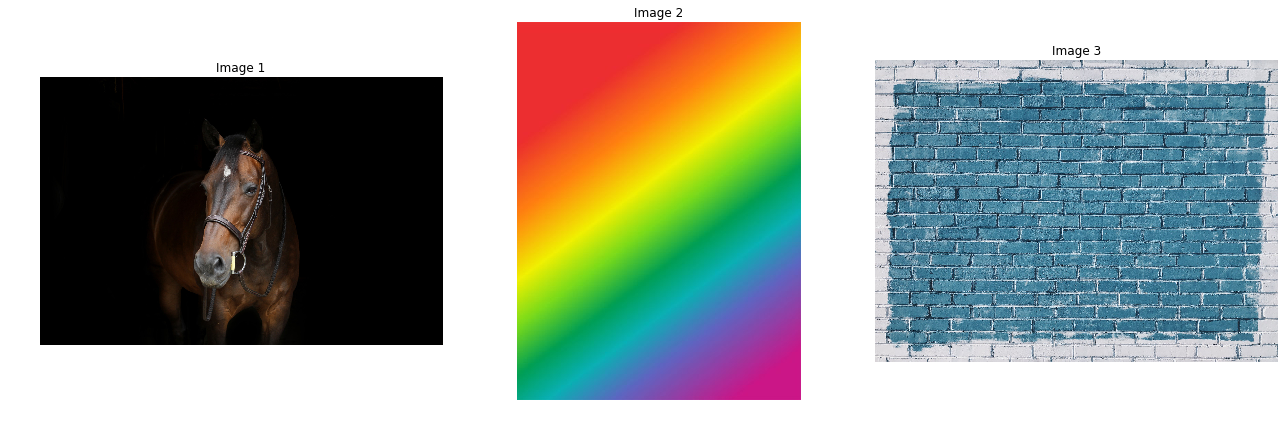

In [4]:
show_imgs(rgb_dark_horse, rgb_rainbow, rgb_bricks)

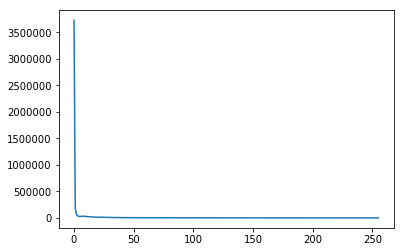

In [5]:
dark_horse_hist = cv2.calcHist([dark_horse], channels=[0], mask=None, histSize=[256], ranges=[0,256])
plt.plot(dark_horse_hist)

In [6]:
dark_horse_hist.shape

(256, 1)

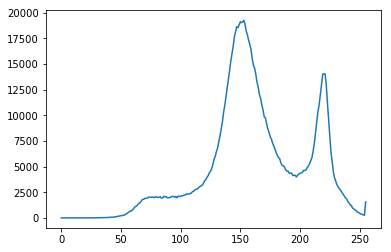

In [7]:
bricks_hist = cv2.calcHist([bricks], channels=[0], mask=None, histSize=[256], ranges=[0,256])
plt.plot(bricks_hist)

Text(0.5,1,'Histogram for Blue Bricks Image')

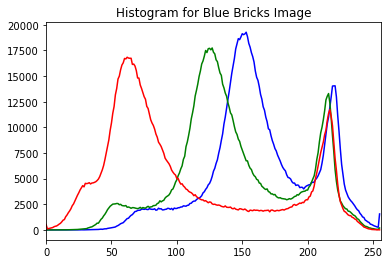

In [8]:
colors = ('b', 'g', 'r')

for i, color in enumerate(colors):
    hist_img = cv2.calcHist([bricks], channels=[i], mask=None, histSize=[256], ranges=[0,256])
    plt.plot(hist_img, color=color)
    plt.xlim([0,256])
    
plt.title('Histogram for Blue Bricks Image')

# Part 2 (Mask on Histogram)

In [9]:
img = rainbow
img.shape

(550, 413, 3)

In [10]:
img.shape[:2]

(550, 413)

In [11]:
mask = np.zeros(img.shape[:2], np.uint8)

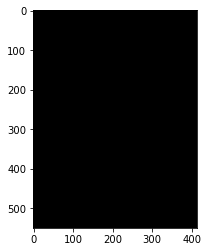

In [12]:
plt.imshow(mask, cmap='gray')

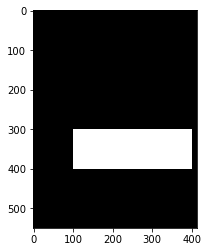

In [13]:
mask[300:400, 100:400] = 255
plt.imshow(mask, cmap='gray')

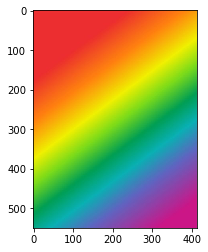

In [14]:
plt.imshow(rgb_rainbow)

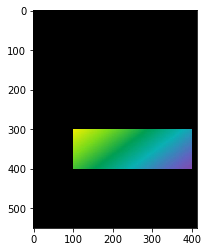

In [15]:
masked_rainbow = cv2.bitwise_and(img, img, mask=mask)
rgb_masked_rainbow = cv2.bitwise_and(rgb_rainbow, rgb_rainbow, mask=mask) # RGB for show
plt.imshow(rgb_masked_rainbow)

Text(0.5,1,'Red Channel Histogram for Masked Rainbow')

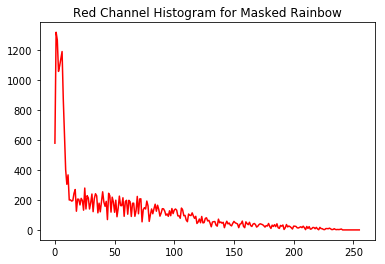

In [16]:
# Red channel Histogram
masked_rainbow_hist_red = cv2.calcHist([rainbow], channels=[2], mask=mask, histSize=[256], ranges=[0,256])
plt.plot(masked_rainbow_hist_red, color='r')
plt.title('Red Channel Histogram for Masked Rainbow')

Text(0.5,1,'Red Channel Histogram for Full Rainbow')

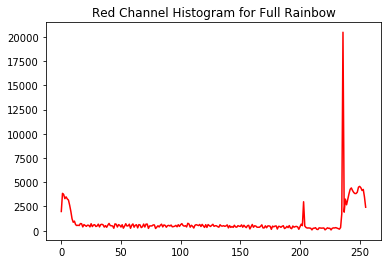

In [17]:
rainbow_hist_red = cv2.calcHist([rainbow], channels=[2], mask=None, histSize=[256], ranges=[0,256])
plt.plot(rainbow_hist_red, color='r')
plt.title('Red Channel Histogram for Full Rainbow')

# Part 3 (Histogram Equalization)

In [18]:
grey_gorilla = cv2.imread("DATA/gorilla.jpg", 0)

In [19]:
def show_img(img):
    fig = plt.figure(figsize=(12,10))
    ax  = fig.add_subplot(111) #(row, col, subplot)
    ax.imshow(img, cmap='gray')

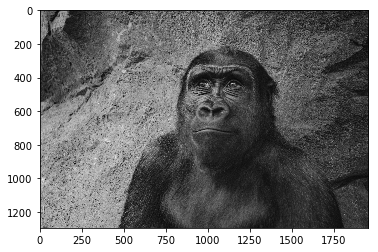

In [20]:
plt.imshow(grey_gorilla, cmap='gray')

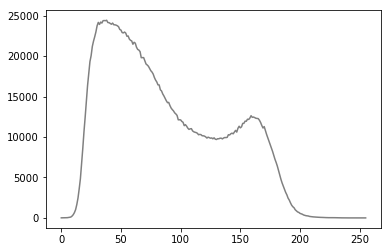

In [21]:
grey_gorilla_hist = cv2.calcHist([grey_gorilla], channels=[0], mask=None, histSize=[256], ranges=[0,256])
plt.plot(grey_gorilla_hist, color='gray')

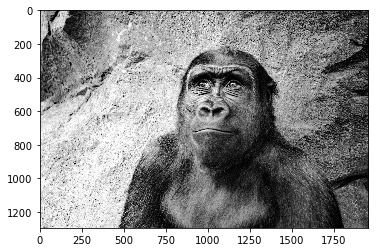

In [22]:
eq_grey_gorilla = cv2.equalizeHist(grey_gorilla)
plt.imshow(eq_grey_gorilla, cmap='gray')

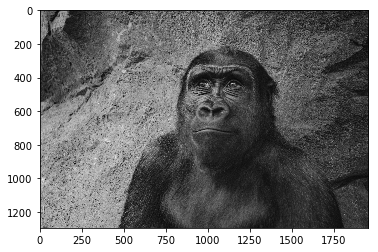

In [23]:
plt.imshow(grey_gorilla, cmap='gray')

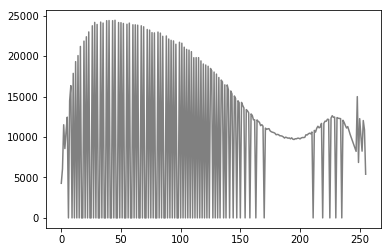

In [24]:
eq_grey_gorilla_hist = cv2.calcHist([eq_grey_gorilla], channels=[0], mask=None, histSize=[256], ranges=[0,256])
plt.plot(eq_grey_gorilla_hist, color='gray')

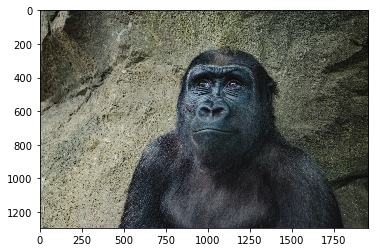

In [25]:
gorilla = cv2.imread("DATA/gorilla.jpg")
rgb_gorilla = cv2.cvtColor(gorilla, cv2.COLOR_BGR2RGB) # RGB for show
plt.imshow(rgb_gorilla)

In [26]:
# To equalize a color image, we need to translate the image to HSV color space first.

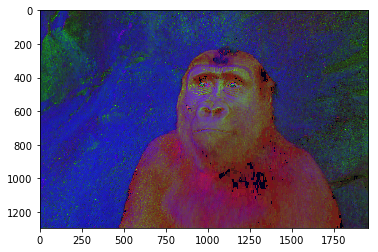

In [27]:
hsv_gorilla = cv2.cvtColor(gorilla, cv2.COLOR_BGR2HSV)
plt.imshow(hsv_gorilla)

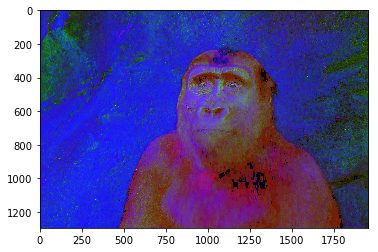

In [28]:
# Now equalize the value channel
hsv_gorilla[:,:,2] = cv2.equalizeHist(hsv_gorilla[:,:,2])
plt.imshow(hsv_gorilla)

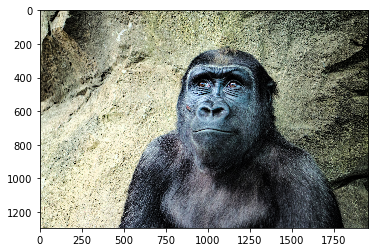

In [29]:
eq_rgb_gorilla = cv2.cvtColor(hsv_gorilla, cv2.COLOR_HSV2RGB)
plt.imshow(eq_rgb_gorilla)

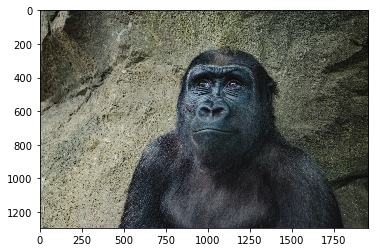

In [30]:
plt.imshow(rgb_gorilla)